In [1]:
print("hola")

hola


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
print("All libraries imported successfully")

All libraries imported successfully


In [13]:
data="../outputs/top/aggregate/metrics_table.parquet"
df = pd.read_parquet(data, engine='pyarrow')
df[df['seed'] == 10].head(10)

,task,seed,subset_id,model,Test Loss,Test Accuracy,Test F1 Score,Test AUC,Test Precision,Test Recall,Confusion Matrix,total_pipeline_time_seconds,Backend,Baseline,Eval Time (s),Random Init
4,top,10,0,classical_base,0.552768,0.716248,0.732577,0.791600,0.692713,0.777308,"[[3101, 1632], [1054, 3679]]",NaN,NaN,None,NaN,None
5,top,10,0,classical_retrained,0.579909,0.687408,0.703655,0.760237,0.668888,0.742235,"[[2994, 1739], [1220, 3513]]",NaN,NaN,None,NaN,None
6,top,10,0,classical_symbolic,0.580074,0.688358,0.704586,0.760317,0.669713,0.743292,"[[2998, 1735], [1215, 3518]]",NaN,NaN,None,NaN,None
7,top,10,0,classical_final,0.579545,0.688147,0.703078,0.760859,0.670954,0.738432,"[[3019, 1714], [1238, 3495]]",2.057202,NaN,None,NaN,None
8,top,10,0,qkan_ideal,0.655896,0.511092,0.671167,0.746439,0.505620,0.997887,"[[115, 4618], [10, 4723]]",NaN,ideal,False,152.970705,None
9,top,10,0,qkan_noisy,0.657836,0.556095,0.683394,0.738472,0.531093,0.958166,"[[729, 4004], [198, 4535]]",NaN,noisy,False,1162.066693,None
10,top,10,0,qkan_baseline_ideal,0.677819,0.500000,0.666667,0.699918,0.500000,1.000000,"[[0, 4733], [0, 4733]]",NaN,ideal,True,147.988942,None
11,top,10,0,qkan_baseline_noisy,0.677249,0.512888,0.671511,0.697600,0.506556,0.995774,"[[142, 4591], [20, 4713]]",NaN,noisy,True,1175.790519,None
12,top,10,0,qkan_random_ideal,0.692522,0.500106,0.478395,0.506897,0.500115,0.458483,"[[2564, 2169], [2563, 2170]]",NaN,ideal,False,211.139342,True
13,top,10,0,random_forest,0.537981,0.743186,0.742233,0.818421,0.744998,0.739489,"[[3535, 1198], [1233, 3500]]",33.764082,NaN,None,NaN,None


In [23]:
df[df['model'] == 'classical_base'].head(10)

,task,seed,subset_id,model,Test Loss,Test Accuracy,Test F1 Score,Test AUC,Test Precision,Test Recall,Confusion Matrix,total_pipeline_time_seconds,Backend,Baseline,Eval Time (s),Random Init
0,top,1,1,classical_base,0.672246,0.643151,0.782827,0.835282,0.643151,1.000000,"[[0, 3121], [0, 5625]]",NaN,NaN,None,NaN,None
4,top,10,0,classical_base,0.552768,0.716248,0.732577,0.791600,0.692713,0.777308,"[[3101, 1632], [1054, 3679]]",NaN,NaN,None,NaN,None
14,top,11,1,classical_base,0.555142,0.712339,0.729727,0.787194,0.688132,0.776674,"[[3067, 1666], [1057, 3676]]",NaN,NaN,None,NaN,None
24,top,12,2,classical_base,0.553452,0.714135,0.730907,0.787868,0.690400,0.776463,"[[3085, 1648], [1058, 3675]]",NaN,NaN,None,NaN,None
34,top,13,3,classical_base,0.552252,0.710649,0.720539,0.791035,0.696725,0.746038,"[[3196, 1537], [1202, 3531]]",NaN,NaN,None,NaN,None
44,top,14,4,classical_base,0.555992,0.707585,0.726103,0.786331,0.682859,0.775195,"[[3029, 1704], [1064, 3669]]",NaN,NaN,None,NaN,None
54,top,2,2,classical_base,0.335748,0.864166,0.897214,0.917095,0.873926,0.921778,"[[2373, 748], [440, 5185]]",NaN,NaN,None,NaN,None
58,top,3,3,classical_base,0.690497,0.613435,0.507800,0.723585,0.698742,0.398817,"[[1960, 407], [1423, 944]]",NaN,NaN,None,NaN,None
64,top,42,2,classical_base,0.246897,0.900592,0.906458,0.955500,0.856308,0.962848,"[[169246, 32651], [7508, 194578]]",NaN,NaN,None,NaN,None
68,top,5,0,classical_base,0.315559,0.872282,0.903024,0.927651,0.876236,0.931503,"[[48757, 14750], [7679, 104428]]",NaN,NaN,None,NaN,None


In [24]:
# Agrupamos por semillas y por modelo, solo considerando las semillas 10..14
df_grouped = df[df['seed'].between(10, 14)].groupby(['seed', 'model']).mean(numeric_only=True).reset_index()
#df_grouped.head(10)
# calculamos el promedio y desviación estandar de cada columna numérica agrupando modelo y calculando por semilla
df_stats = df_grouped.groupby('model').agg(['mean', 'std']).reset_index()
df_stats.head(10)

model  seed           subset_id           Test Loss  \
                        mean       std      mean       std      mean   
0       classical_base  12.0  1.581139       2.0  1.581139  0.553921   
1      classical_final  12.0  1.581139       2.0  1.581139  0.581599   
2  classical_retrained  12.0  1.581139       2.0  1.581139  0.582971   
3   classical_symbolic  12.0  1.581139       2.0  1.581139  0.583203   
4  qkan_baseline_ideal  12.0  1.581139       2.0  1.581139  0.671309   
5  qkan_baseline_noisy  12.0  1.581139       2.0  1.581139  0.672247   
6           qkan_ideal  12.0  1.581139       2.0  1.581139  0.657375   
7           qkan_noisy  12.0  1.581139       2.0  1.581139  0.659338   
8    qkan_random_ideal  12.0  1.581139       2.0  1.581139  0.692918   
9        random_forest  12.0  1.581139       2.0  1.581139  0.539056   

            Test Accuracy           Test F1 Score  ...  Test AUC            \
        std          mean       std          mean  ...      mean       std   
0  0.001590      0.712191  0.003311      0.727971  ...  0.788806  0.002365   
1  0.002886      0.687070  0.005078      0.697627  ...  0.757363  0.004266   
2  0.002753      0.686309  0.004507      0.699074  ...  0.755920  0.003789   
3  0.002725      0.686330  0.004462      0.699755  ...  0.755569  0.003978   
4  0.003721      0.541010  0.027471      0.680432  ...  0.698041  0.003506   
5  0.002860      0.539489  0.017728      0.676574  ...  0.693299  0.003574   
6  0.001710      0.554046  0.026784      0.686700  ...  0.739226  0.006276   
7  0.001642      0.568202  0.013234      0.687428  ...  0.732853  0.005438   
8  0.000257      0.510522  0.028766      0.495001  ...  0.527268  0.048641   
9  0.002723      0.743989  0.003588      0.743955  ...  0.819207  0.004423   

  Test Precision           Test Recall           total_pipeline_time_seconds  \
            mean       std        mean       std                        mean   
0       0.690166  0.005174    0.770336  0.013604                         NaN   
1       0.674815  0.003950    0.722164  0.014578                  353.910552   
2       0.671715  0.004339    0.728967  0.016886                         NaN   
3       0.670982  0.002841    0.731249  0.015248                         NaN   
4       0.522582  0.015651    0.976336  0.023112                         NaN   
5       0.521741  0.010383    0.963026  0.022890                         NaN   
6       0.529867  0.015462    0.976463  0.016607                         NaN   
7       0.538863  0.008534    0.949377  0.008064                         NaN   
8       0.512382  0.029380    0.481513  0.052845                         NaN   
9       0.744037  0.002927    0.743883  0.005808                   34.243198   

              Eval Time (s)               
          std          mean          std  
0         NaN           NaN          NaN  
1  481.998025           NaN          NaN  
2         NaN           NaN          NaN  
3         NaN           NaN          NaN  
4         NaN    167.351713    15.151324  
5         NaN   4238.165100  2909.397297  
6         NaN    174.882717    13.494079  
7         NaN   4274.187191  2928.542654  
8         NaN    190.118208    17.716946  
9    1.959615           NaN          NaN  

[10 rows x 21 columns]

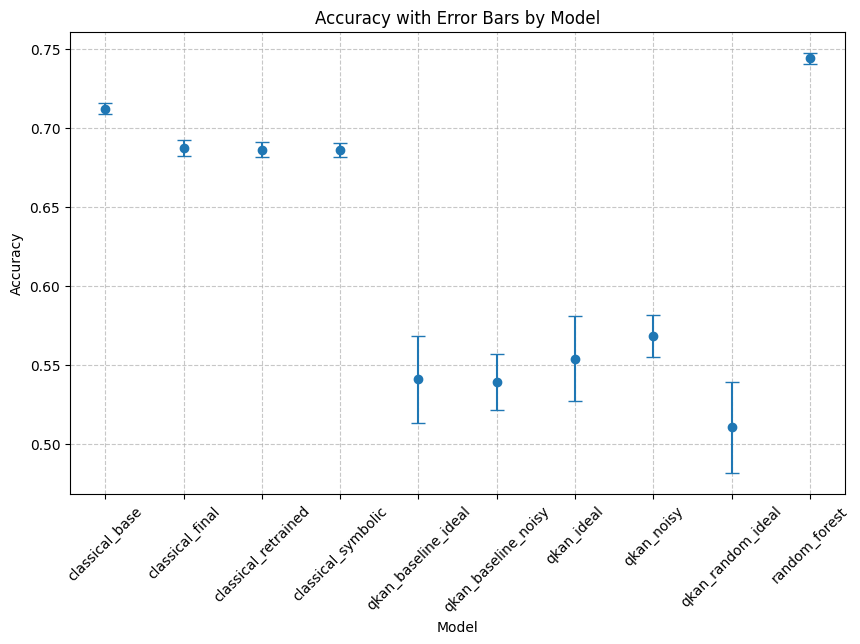

In [25]:
#grafica de accuracy con barra de error 
plt.figure(figsize=(10, 6))
plt.errorbar(df_stats['model'], df_stats['Test Accuracy']['mean'], 
            yerr=df_stats['Test Accuracy']['std'], fmt='o', capsize=5) 
# rotamos label de modelo 45 grados
plt.xticks(rotation=45)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy with Error Bars by Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

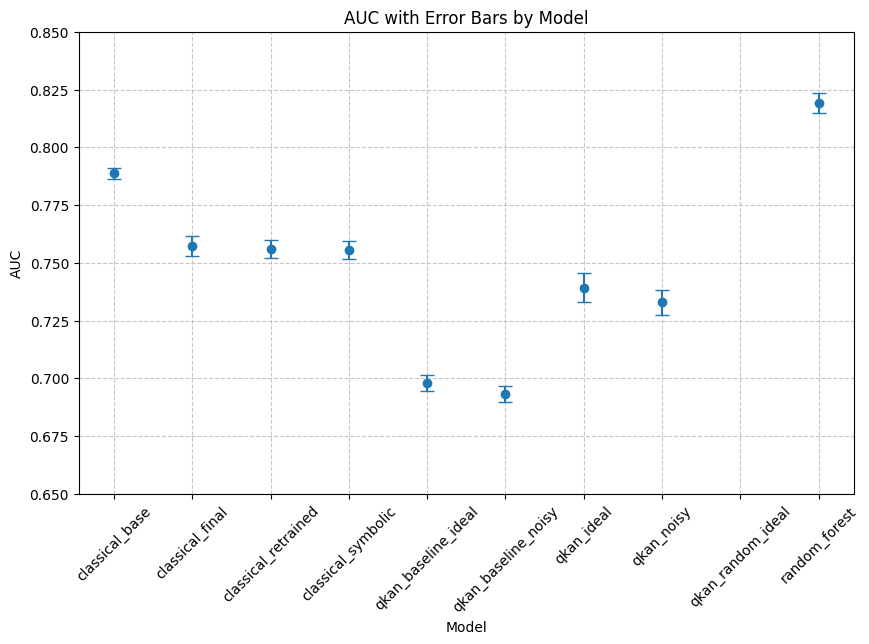

In [29]:
#grafica de accuracy con barra de error 
plt.figure(figsize=(10, 6))
plt.errorbar(df_stats['model'], df_stats['Test AUC']['mean'], 
            yerr=df_stats['Test AUC']['std'], fmt='o', capsize=5) 
# rotamos label de modelo 45 grados
plt.xticks(rotation=45)
plt.xlabel('Model')
plt.ylabel('AUC')
plt.title('AUC with Error Bars by Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.65,0.85)
plt.show()

In [ ]:
hfhdrdfghrt 